In [3]:
import yfinance as yf
import pandas as pd
import talib
import matplotlib.pyplot as plt

ticker = 'AAPL'
df = yf.download(ticker, start="2020-01-01", end="2023-12-31")

close_data = df['Close'].values.astype(float).flatten()


df['SMA_20'] = talib.SMA(close_data, timeperiod=20)
df['EMA_20'] = talib.EMA(close_data, timeperiod=20)
df['RSI'] = talib.RSI(close_data, timeperiod=14)

macd, macdsignal, macdhist = talib.MACD(close_data)
df['macd'] = macd
df['macdsignal'] = macdsignal
df['macdhist'] = macdhist

print("Success! Indicators computed.")
print(df[['Close', 'SMA_20', 'RSI']].tail())

[*********************100%***********************]  1 of 1 completed


Success! Indicators computed.
Price            Close      SMA_20        RSI
Ticker            AAPL                       
Date                                         
2023-12-22  191.609451  191.677257  54.672764
2023-12-26  191.065125  191.838581  53.090053
2023-12-27  191.164093  191.974668  53.354454
2023-12-28  191.589661  192.183003  54.540971
2023-12-29  190.550476  192.310678  51.121371


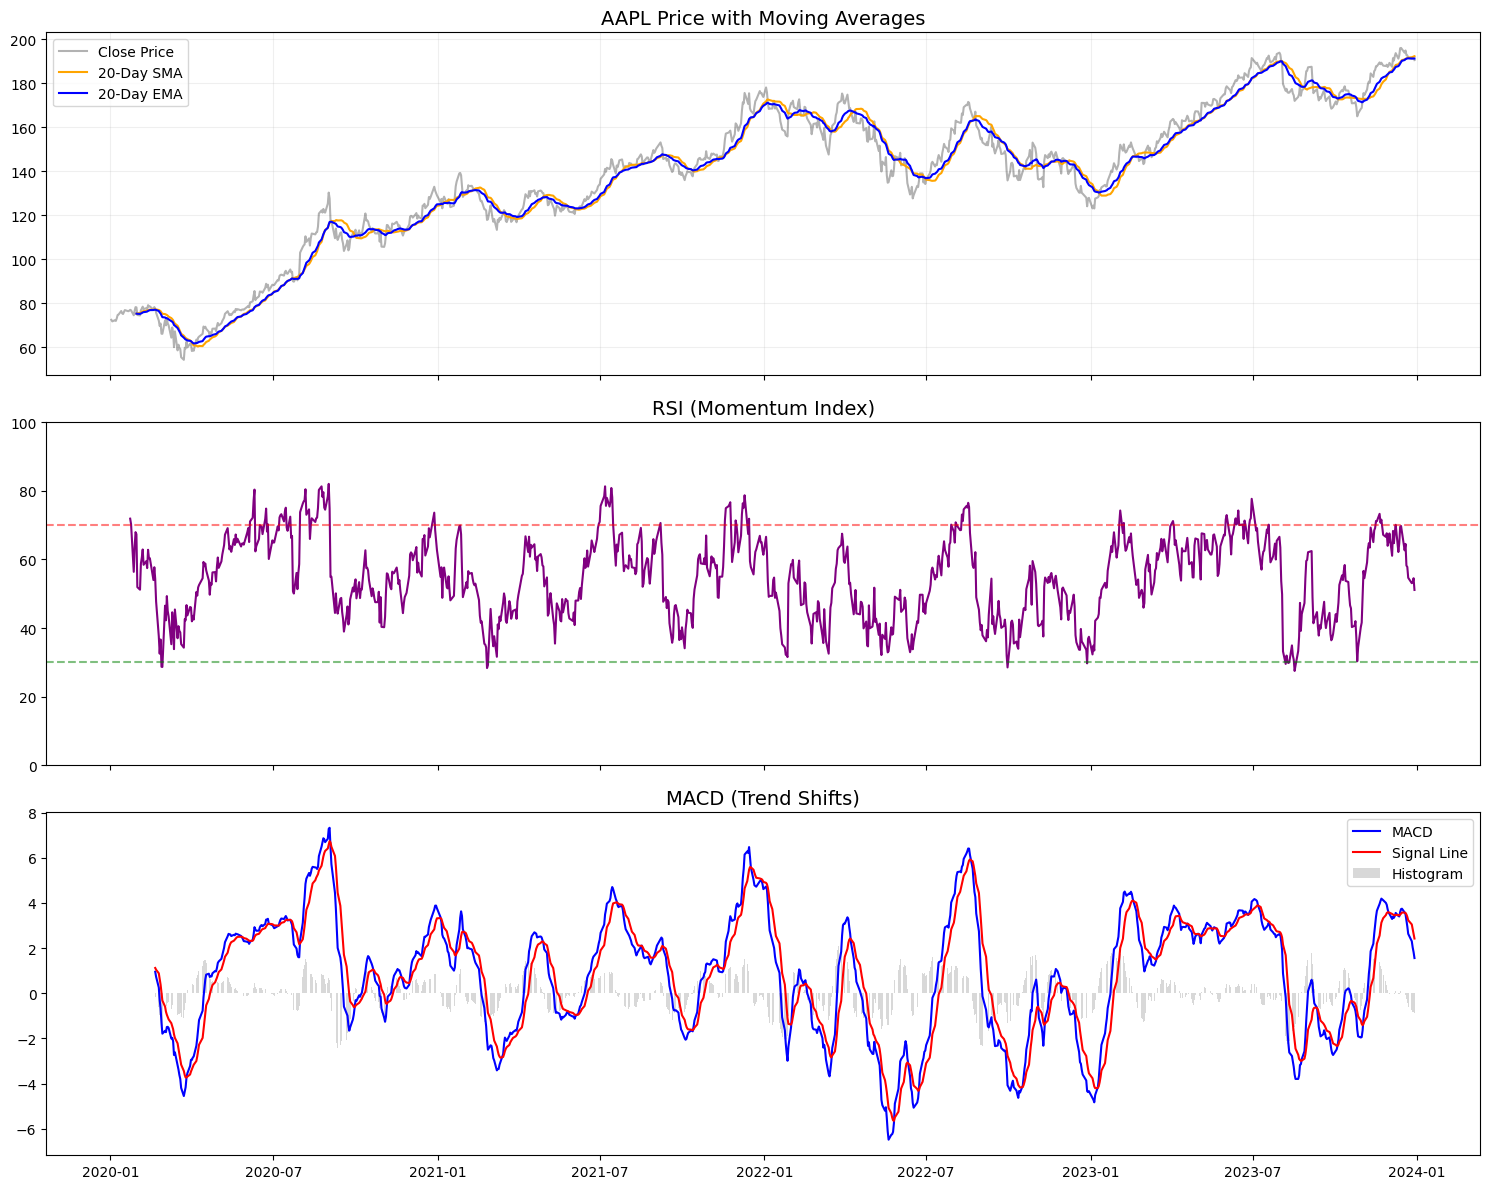

In [4]:
import matplotlib.pyplot as plt


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)


ax1.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.3)
ax1.plot(df.index, df['SMA_20'], label='20-Day SMA', color='orange', linewidth=1.5)
ax1.plot(df.index, df['EMA_20'], label='20-Day EMA', color='blue', linewidth=1.5)
ax1.set_title(f'{ticker} Price with Moving Averages', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.2)


ax2.plot(df.index, df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought line
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold line
ax2.set_title('RSI (Momentum Index)', fontsize=14)
ax2.set_ylim(0, 100)


ax3.plot(df.index, df['macd'], label='MACD', color='blue')
ax3.plot(df.index, df['macdsignal'], label='Signal Line', color='red')
ax3.bar(df.index, df['macdhist'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD (Trend Shifts)', fontsize=14)
ax3.legend(loc='best')

plt.tight_layout()
plt.show()

In [8]:

# 1. Calculate Daily Returns (Standard financial metric)
df['daily_return'] = df['Close'].pct_change()

# 2. Calculate Rolling 20-Day Volatility 
# This shows how much the price "swings"
df['volatility'] = df['daily_return'].rolling(window=20).std()

# 3. Calculate Cumulative Return (Total growth over time)
df['cum_return'] = (1 + df['daily_return']).cumprod() - 1

# 4. Handle any 'NaN' created by the rolling windows
df.dropna(inplace=True)

print("Financial Metrics Computed Successfully:")
print(df[['daily_return', 'volatility', 'cum_return']].tail())

Financial Metrics Computed Successfully:
Price      daily_return volatility cum_return
Ticker                                       
Date                                         
2023-12-22    -0.005547   0.009071   1.646520
2023-12-26    -0.002841   0.009103   1.639002
2023-12-27     0.000518   0.009086   1.640368
2023-12-28     0.002226   0.008973   1.646246
2023-12-29    -0.005424   0.009078   1.631893
